**TIME SERIES PREDICTION**

Bike Sharing Dataset (Evaluating the efficacy of RNN, LSTM and GRU models and their modified versions)

Import libraries and packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, GRU
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import Adam
from keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

In [ ]:
# Ensure reproducibility
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

# Data Loading & EDA

Data Loading

In [ ]:
# Loading dataset
df = pd.read_csv('day.csv', parse_dates = ['dteday'], index_col = 'dteday')

**Exploratory Data Analysis**

In [ ]:
# Checking data columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2011-01-01 to 2012-12-31
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   season      731 non-null    int64  
 2   yr          731 non-null    int64  
 3   mnth        731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 91.4 KB


In [ ]:
# Number of rows and columns of dataset
df.shape

(731, 15)

In [ ]:
# Print last 5 observations of data
df.tail()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,,,
2012-12-27,727,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
2012-12-28,728,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
2012-12-29,729,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
2012-12-30,730,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
2012-12-31,731,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [ ]:
# Check for duplicates and nulls
print("Num of duplicates: {}".format(df.duplicated().sum()))
print("Num of nulls: {}".format(df.isnull().sum()))

Num of duplicates: 0
Num of nulls: instant       0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
# If int64, print each category
def print_category_names(df):
  for column in df.select_dtypes(include='int64'):
    if df[column].nunique() < 10:
      print(f"Category for '{column}':")
      print(df[column].unique())

print_category_names(df)

Category for 'season':
[1 2 3 4]
Category for 'yr':
[0 1]
Category for 'holiday':
[0 1]
Category for 'weekday':
[6 0 1 2 3 4 5]
Category for 'workingday':
[0 1]
Category for 'weathersit':
[2 1 3]


**Description of features:**

*   dteday : date
*   season : season (1:winter, 2:spring, 3:summer, 4:fall)
*   yr : year (0: 2011, 1:2012)
*   mnth : month ( 1 to 12)
*   holiday : Day is holiday or not
*   weekday : day of the week
*   workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
*   weathersit : Weather situation

1.   Clear, Few clouds, Partly cloudy, Partly cloudy
2.   Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3.   Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

*   temp : Normalized temperature in Celsius.
*   atemp: Normalized feeling temperature in Celsius.
*   hum: Normalized humidity.
*   windspeed: Normalized wind speed.
*   casual: count of casual users
*   registered: count of registered users
*   cnt: count of total rental bikes including both casual and registered

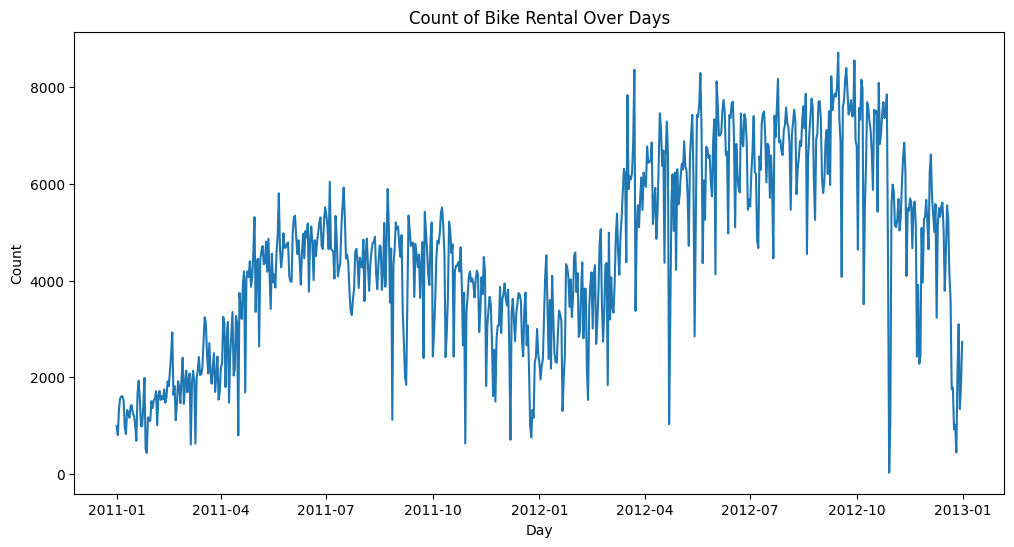

In [ ]:
# Plot on total count of bike rentals over the days

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="dteday", y="cnt")
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Count of Bike Rental Over Days")
plt.show()

In [ ]:
# Descriptive statistics of dataset
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Text(0.5, 1.0, 'Number of bikes rented per season')

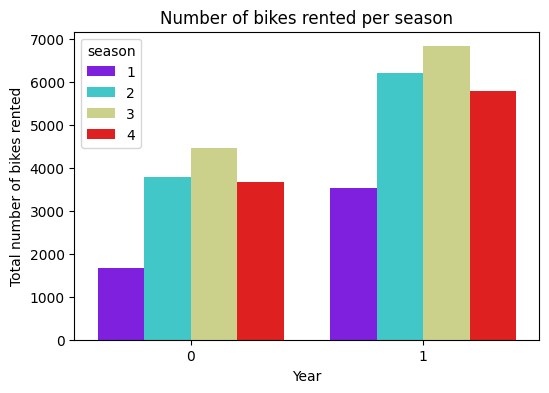

In [ ]:
# Plot barplot for bikes per season (To see overall need of bikes per season separated by years)
plt.figure(figsize=(6,4))
sns.barplot(x='yr', y='cnt', hue='season', data=df, palette='rainbow', errorbar= None)
plt.xlabel('Year')
plt.ylabel('Total number of bikes rented')
plt.title('Number of bikes rented per season')

In [ ]:
# Define barplot for bike counts per category

def plot_bikes_per_category(df, category):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=category, y='cnt', hue='yr', data=df, palette='rainbow', errorbar=None)
    plt.xlabel(category.capitalize())
    plt.ylabel('Total number of bikes rented')
    plt.title(f'Number of bikes rented per {category} per year')
    plt.legend(title='Year', loc='upper left')
    plt.show()

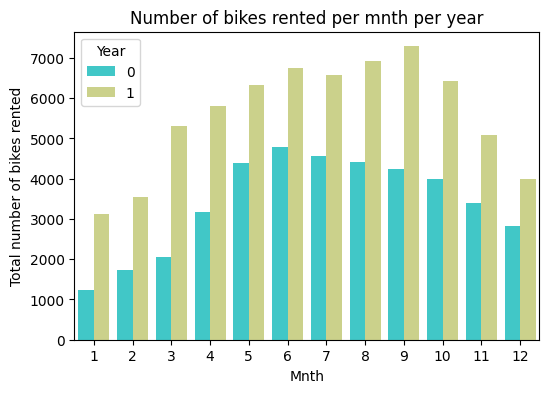

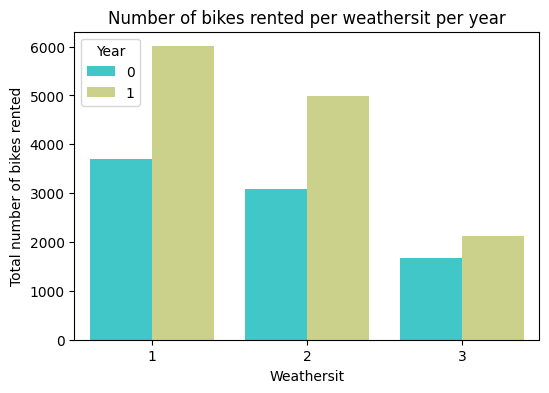

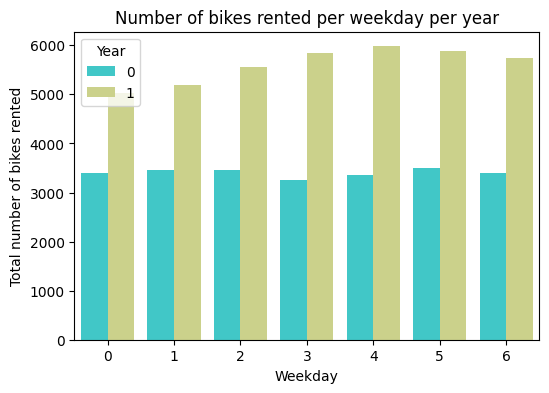

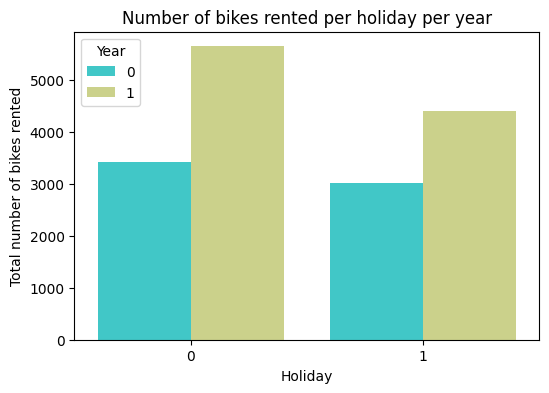

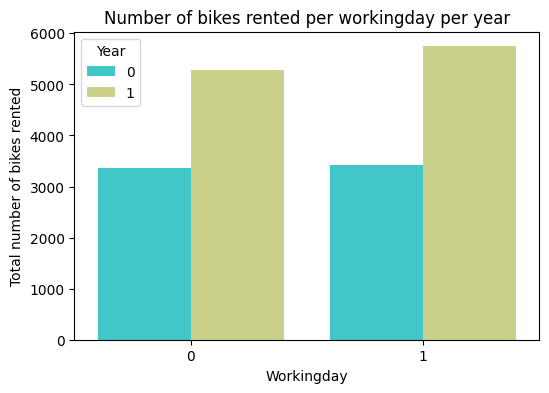

In [ ]:
plot_bikes_per_category(df, 'mnth')
plot_bikes_per_category(df, 'weathersit')
plot_bikes_per_category(df, 'weekday')
plot_bikes_per_category(df, 'holiday')
plot_bikes_per_category(df, 'workingday')

<ipython-input-14-150d8924f5a5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='rainbow')


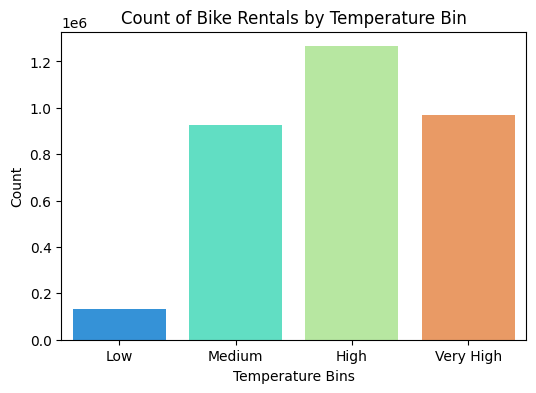

In [ ]:
# Plot total bike rentals based on temperatures (Binned based on 4 categories just for visualization)

# Create a new column for temperature bins
df['temp_bins'] = pd.cut(df['temp'], bins=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Group the data by temperature bin and calculate the number of rentals
grouped_data = df.groupby('temp_bins')['cnt'].sum()

# Plot the bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='rainbow')
plt.xlabel('Temperature Bins')
plt.ylabel('Count')
plt.title('Count of Bike Rentals by Temperature Bin')
plt.show()

In [ ]:
# Days with total bike rentals lower than 100
df_low_rentals = df[df['cnt'] < 100]
print(df_low_rentals)

            instant  season  yr  mnth  holiday  weekday  workingday  \
dteday                                                                
2012-10-29      668       4   1    10        0        1           1   

            weathersit  temp   atemp   hum  windspeed  casual  registered  \
dteday                                                                      
2012-10-29           3  0.44  0.4394  0.88     0.3582       2          20   

            cnt temp_bins  
dteday                     
2012-10-29   22    Medium  


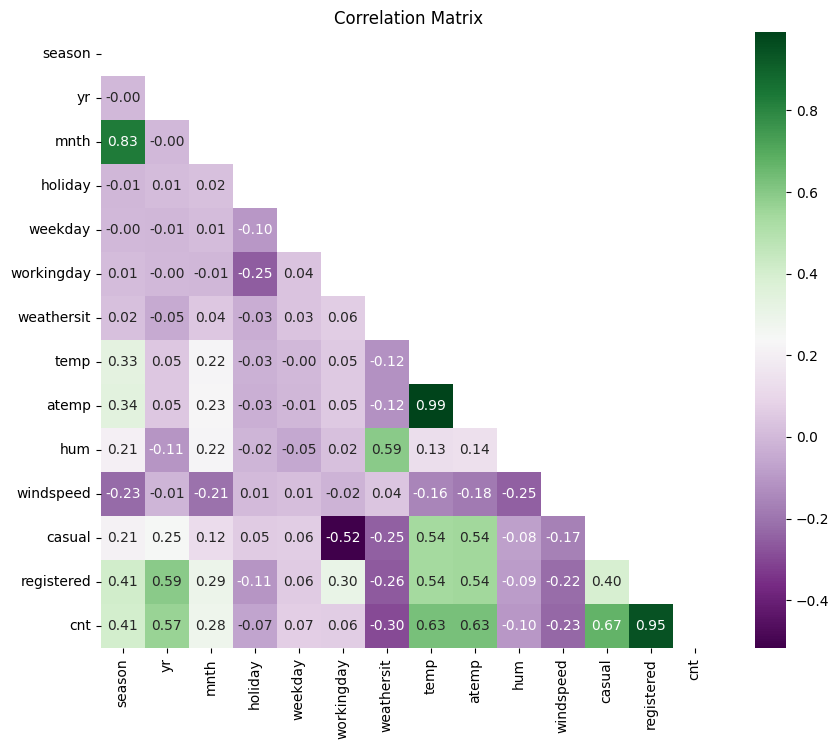

In [ ]:
# Plot correlation heatmap
corr_matrix = df[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, mask=mask, fmt=".2f", cmap='PRGn', square=True)
plt.title('Correlation Matrix')
plt.show()

# Data Pre-processing


Mean Imputation for outliers

In [ ]:
# Calculate average cnt, casual and registered for mnth 10 yr 1
average_cnt = df.loc[(df['mnth'] == 10) & (df['yr'] == 1), 'cnt'].mean()
print(f"Average cnt: {average_cnt}")

Average cnt: 6414.225806451613


In [ ]:
# Mean Imputation
# Replace cnt on 2012-10-29 to the average_cnt
df.loc['2012-10-29', ['cnt']] = [average_cnt]
print(df.loc['2012-10-29'])

instant               668
season                  4
yr                      1
mnth                   10
holiday                 0
weekday                 1
workingday              1
weathersit              3
temp                 0.44
atemp              0.4394
hum                  0.88
windspeed          0.3582
casual                  2
registered             20
cnt           6414.225806
temp_bins          Medium
Name: 2012-10-29 00:00:00, dtype: object


**Cylical encoding for features with cyclical pattterns**
- To preserve its cyclical nature

In [ ]:
# Cylical encoding for cylical features

# Encode month
max_month = 12
df['mnth_sin'] = np.sin(2 * np.pi * df['mnth'] / max_month)
df['mnth_cos'] = np.cos(2 * np.pi * df['mnth'] / max_month)

# Encode day of the week
max_day_of_week = 7
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / max_day_of_week)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / max_day_of_week)

# Encode season
max_season = 4
df['season_sin'] = np.sin(2 * np.pi * df['season'] / max_season)
df['season_cos'] = np.cos(2 * np.pi * df['season'] / max_season)

# Show the resulting DataFrame
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,...,casual,registered,cnt,temp_bins,mnth_sin,mnth_cos,weekday_sin,weekday_cos,season_sin,season_cos
dteday,,,,,,,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,...,331,654,985.0,Medium,0.5,0.866025,-0.781831,0.623490,1.0,6.123234e-17
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,...,131,670,801.0,Medium,0.5,0.866025,0.000000,1.000000,1.0,6.123234e-17
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,...,120,1229,1349.0,Low,0.5,0.866025,0.781831,0.623490,1.0,6.123234e-17
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,...,108,1454,1562.0,Low,0.5,0.866025,0.974928,-0.222521,1.0,6.123234e-17
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,...,82,1518,1600.0,Low,0.5,0.866025,0.433884,-0.900969,1.0,6.123234e-17


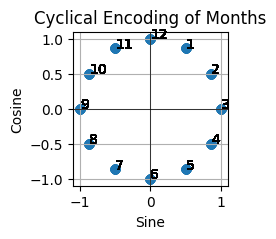

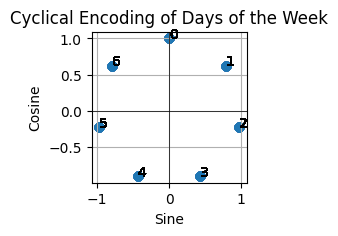

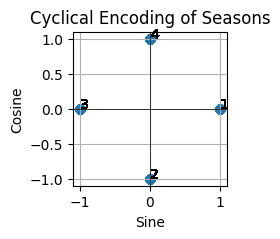

In [ ]:
# Visualizing the cyclical features after encoding

# Plot for Months
plt.figure(figsize=(2, 2))
plt.scatter(df['mnth_sin'], df['mnth_cos'])
for i, txt in enumerate(df['mnth']):
    plt.annotate(txt, (df['mnth_sin'].iloc[i], df['mnth_cos'].iloc[i]))
plt.title('Cyclical Encoding of Months')
plt.xlabel('Sine')
plt.ylabel('Cosine')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True)
plt.show()

# Plot for Weeks
plt.figure(figsize=(2, 2))
plt.scatter(df['weekday_sin'], df['weekday_cos'])
for i, txt in enumerate(df['weekday']):
    plt.annotate(txt, (df['weekday_sin'].iloc[i], df['weekday_cos'].iloc[i]))
plt.title('Cyclical Encoding of Days of the Week')
plt.xlabel('Sine')
plt.ylabel('Cosine')
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.show()

# Plot for Seasons
plt.figure(figsize=(2, 2))
plt.scatter(df['season_sin'], df['season_cos'])
for i, txt in enumerate(df['season']):
    plt.annotate(txt, (df['season_sin'].iloc[i], df['season_cos'].iloc[i]))
plt.title('Cyclical Encoding of Seasons')
plt.xlabel('Sine')
plt.ylabel('Cosine')
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.show()

**One-hot-encoding**

In [ ]:
# One-hot encoding for categorical features
df_encode = pd.get_dummies(df, columns=['yr', 'holiday', 'workingday', 'weathersit'], prefix=['yr', 'holiday', 'workingday', 'weathersit'])

# Convert boolean columns (True/False) to integers (1/0)
boolean_cols = df_encode.select_dtypes(include=bool).columns
df_encode[boolean_cols] = df_encode[boolean_cols].astype(int)

print(df_encode.head())

            instant  season  mnth  weekday      temp     atemp       hum  \
dteday                                                                     
2011-01-01        1       1     1        6  0.344167  0.363625  0.805833   
2011-01-02        2       1     1        0  0.363478  0.353739  0.696087   
2011-01-03        3       1     1        1  0.196364  0.189405  0.437273   
2011-01-04        4       1     1        2  0.200000  0.212122  0.590435   
2011-01-05        5       1     1        3  0.226957  0.229270  0.436957   

            windspeed  casual  registered  ...    season_cos yr_0  yr_1  \
dteday                                     ...                            
2011-01-01   0.160446     331         654  ...  6.123234e-17    1     0   
2011-01-02   0.248539     131         670  ...  6.123234e-17    1     0   
2011-01-03   0.248309     120        1229  ...  6.123234e-17    1     0   
2011-01-04   0.160296     108        1454  ...  6.123234e-17    1     0   
2011-01-05   0.18

**Normalization**
- For feature 'cnt' : Mix-max scaling to range of 0 and 1
- The original dataset has normalized all other features (Except casual, registered and cnt, however, won't be using casual and registered)

- Normalizing the cyclical encoded features to range of 0 and 1 as well to ensure consistency.
- Normalized by simple transformation. Shifts and rescale the sine and cosine encoded values by mapping -1 to 1 to 0 to 1
(Formula: (Value+1)/2) as it was previously encoded by sine and cosine transformation. Minmaxscaler might distort the cyclical relationship.

In [ ]:
# Normalizing 'cnt' using minmax scaler to 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
df_encode['cnt'] = scaler.fit_transform(df_encode['cnt'].values.reshape(-1, 1))

In [ ]:
# Normalize the cyclical encoded features to the range 0 to 1
df_encode['mnth_sin_norm'] = (df['mnth_sin'] + 1) / 2
df_encode['mnth_cos_norm'] = (df['mnth_cos'] + 1) / 2
df_encode['weekday_sin_norm'] = (df['weekday_sin'] + 1) / 2
df_encode['weekday_cos_norm'] = (df['weekday_cos'] + 1) / 2
df_encode['season_sin_norm'] = (df['season_sin'] + 1) / 2
df_encode['season_cos_norm'] = (df['season_cos'] + 1) / 2

In [ ]:
# Check dataframe columns after all encoding and normalization
df_encode.columns

Index(['instant', 'season', 'mnth', 'weekday', 'temp', 'atemp', 'hum',
       'windspeed', 'casual', 'registered', 'cnt', 'temp_bins', 'mnth_sin',
       'mnth_cos', 'weekday_sin', 'weekday_cos', 'season_sin', 'season_cos',
       'yr_0', 'yr_1', 'holiday_0', 'holiday_1', 'workingday_0',
       'workingday_1', 'weathersit_1', 'weathersit_2', 'weathersit_3',
       'mnth_sin_norm', 'mnth_cos_norm', 'weekday_sin_norm',
       'weekday_cos_norm', 'season_sin_norm', 'season_cos_norm'],
      dtype='object')

In [ ]:
# Removing unwanted columns

# Creating list of columns to drop
#col_to_drop = ['season', 'mnth', 'weekday', 'registered', 'casual']
#col_to_drop = ['season', 'mnth', 'weekday', 'registered', 'casual',  'mnth_cos', 'mnth_sin', 'season_sin', 'season_cos', 'weekday_sin', 'weekday_cos']
#col_to_drop = ['hum', 'windspeed', 'season', 'mnth', 'weekday', 'registered', 'casual',  'mnth_cos', 'mnth_sin', 'season_sin', 'season_cos', 'weekday_sin', 'weekday_cos']
#col_to_drop = ['season', 'mnth', 'weekday', 'registered', 'casual', 'temp_bins', 'mnth_cos', 'mnth_sin', 'season_sin', 'season_cos', 'weekday_sin', 'weekday_cos']
col_to_drop = ['instant', 'season', 'mnth', 'weekday', 'registered', 'temp_bins', 'casual', 'hum', 'mnth_cos', 'mnth_sin', 'season_sin', 'season_cos']

# Drop the unnecessary columns for final dataframe
df_final = df_encode.drop(columns=col_to_drop)
df_final.columns

Index(['temp', 'atemp', 'windspeed', 'cnt', 'weekday_sin', 'weekday_cos',
       'yr_0', 'yr_1', 'holiday_0', 'holiday_1', 'workingday_0',
       'workingday_1', 'weathersit_1', 'weathersit_2', 'weathersit_3',
       'mnth_sin_norm', 'mnth_cos_norm', 'weekday_sin_norm',
       'weekday_cos_norm', 'season_sin_norm', 'season_cos_norm'],
      dtype='object')

In [ ]:
# Descriptive statistics of final dataframe
# Final check if everything is normalized and transformed accordingly
df_final.describe()

,temp,atemp,windspeed,cnt,weekday_sin,weekday_cos,yr_0,yr_1,holiday_0,holiday_1,...,workingday_1,weathersit_1,weathersit_2,weathersit_3,mnth_sin_norm,mnth_cos_norm,weekday_sin_norm,weekday_cos_norm,season_sin_norm,season_cos_norm
count,731.000000,731.000000,731.000000,731.000000,7.310000e+02,731.000000,731.000000,731.000000,731.000000,731.000000,...,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.190486,0.492828,6.986356e-18,0.003074,0.499316,0.500684,0.971272,0.028728,...,0.683995,0.633379,0.337893,0.028728,0.497905,0.499157,0.500000,0.501537,0.495212,0.495896
std,0.183051,0.162961,0.077498,0.233173,7.073223e-01,0.707853,0.500342,0.500342,0.167155,0.167155,...,0.465233,0.482212,0.473316,0.167155,0.353184,0.354399,0.353661,0.353926,0.355453,0.352073
min,0.059130,0.079070,0.022392,0.000000,-9.749279e-01,-0.900969,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012536,0.049516,0.000000,0.000000
25%,0.337083,0.337842,0.134950,0.331462,-7.818315e-01,-0.900969,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.066987,0.066987,0.109084,0.049516,0.000000,0.000000
50%,0.498333,0.486733,0.180975,0.497163,0.000000e+00,-0.222521,0.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.500000,0.500000,0.500000,0.388740,0.500000,0.500000
75%,0.655417,0.608602,0.233214,0.670047,7.818315e-01,0.623490,1.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.750000,0.933013,0.890916,0.811745,0.500000,0.500000
max,0.861667,0.840896,0.507463,1.000000,9.749279e-01,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.987464,1.000000,1.000000,1.000000


In [ ]:
df_final.shape

(731, 21)

# Data Splitting

**Data Spltting**
- Time series based split
- First 70% (by sequence) are used for training
- 20% for validation, 10% for testing

In [ ]:
# Data Splitting without randomness

# Calculate indices for splits
train_size = int(len(df_final) * 0.7)
val_size = int(len(df_final) * 0.2)

# Split data manually to preserve time order
X_train = df_final.iloc[:train_size].drop('cnt', axis=1)
y_train = df_final.iloc[:train_size]['cnt']
X_val = df_final.iloc[train_size:train_size+val_size].drop('cnt', axis=1)
y_val = df_final.iloc[train_size:train_size+val_size]['cnt']
X_test = df_final.iloc[train_size+val_size:].drop('cnt', axis=1)
y_test = df_final.iloc[train_size+val_size:]['cnt']

# Print the shapes of the splits
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (511, 20)
y_train shape: (511,)
X_val shape: (146, 20)
y_val shape: (146,)
X_test shape: (74, 20)
y_test shape: (74,)


In [ ]:
# Parameters for TimeseriesGenerator
n_input = 10  # Number of time steps to look back
batch_size = 5  # Number of time series samples in each batch

# Create TimeseriesGenerators
train_generator = TimeseriesGenerator(X_train.values, y_train.values, length=n_input, batch_size=batch_size, shuffle=False)
val_generator = TimeseriesGenerator(X_val.values, y_val.values, length=n_input, batch_size=batch_size, shuffle= False)
test_generator = TimeseriesGenerator(X_test.values, y_test.values, length=n_input, batch_size=batch_size, shuffle=False)

In [ ]:
# Verify sizes of the generated splits & percentage split
# Sizes after timeseriesgenerator with n_input = 10 and batch_size = 3

def print_generator_info(generator, name, total_rows): # Added total_rows as a parameter
    # Total number of samples the generator will produce
    num_samples = len(generator)

    # Calculate the percentage of the total data
    percentage = (num_samples / total_rows) * 100

    print(f'{name} Generator:')
    print(f'  Total samples: {num_samples}')
    print(f'  Percentage of total data: {percentage:.2f}%')
    print()

# Calculate total rows
total_rows = len(df_final)

# Display info for each generator
print_generator_info(train_generator, 'Training', total_rows)
print_generator_info(val_generator, 'Validation', total_rows)
print_generator_info(test_generator, 'Testing', total_rows)

Training Generator:
  Total samples: 101
  Percentage of total data: 13.82%

Validation Generator:
  Total samples: 28
  Percentage of total data: 3.83%

Testing Generator:
  Total samples: 13
  Percentage of total data: 1.78%



# Data Modelling: SimpleRNN

In [ ]:
# Define the model architecture
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation = 'tanh', input_shape=(n_input, X_train.shape[1])))
rnn_model.add(Dense(1, activation = 'relu'))

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

rnn_model.compile(optimizer=optimizer, loss='mse')

In [ ]:
# Model summary
rnn_model.summary()

Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_19 (SimpleRNN)   (None, 50)                3550      
                                                                 
 dense_41 (Dense)            (None, 1)                 51        
                                                                 
Total params: 3601 (14.07 KB)
Trainable params: 3601 (14.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Fit the model with the generators
rnn_history = rnn_model.fit(train_generator, epochs=120, validation_data=val_generator)

Epoch 1/120
101/101 [==============================] - 2s 7ms/step - loss: 0.1458 - val_loss: 0.3391
Epoch 2/120
101/101 [==============================] - 1s 5ms/step - loss: 0.1291 - val_loss: 0.3009
Epoch 3/120
101/101 [==============================] - 1s 5ms/step - loss: 0.1086 - val_loss: 0.1127
Epoch 4/120
101/101 [==============================] - 1s 5ms/step - loss: 0.0326 - val_loss: 0.0475
Epoch 5/120
101/101 [==============================] - 1s 5ms/step - loss: 0.0232 - val_loss: 0.0456
Epoch 6/120
101/101 [==============================] - 1s 5ms/step - loss: 0.0201 - val_loss: 0.0413
Epoch 7/120
101/101 [==============================] - 1s 5ms/step - loss: 0.0186 - val_loss: 0.0464
Epoch 8/120
101/101 [==============================] - 1s 5ms/step - loss: 0.0171 - val_loss: 0.0397
Epoch 9/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0166 - val_loss: 0.0401
Epoch 10/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0152 - val_lo

In [ ]:
# Printing train loss, validation loss and MSE
train_loss = rnn_history.history['loss']
val_loss = rnn_history.history['val_loss']

# Final train and validation loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validation loss achieved
best_train_loss = min(rnn_history.history['loss'])
best_val_loss = min(rnn_history.history['val_loss'])

test_loss = rnn_model.evaluate(test_generator)

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')
print(f'Test Loss (MSE): {test_loss}')

13/13 [==============================] - 0s 3ms/step - loss: 0.0330
Training Loss (MSE): 0.005300840828567743
Validation Loss (MSE): 0.03983881324529648
Best Training Loss (MSE): 0.005261528305709362
Best Validation Loss (MSE): 0.03382427617907524
Test Loss (MSE): 0.03298076614737511


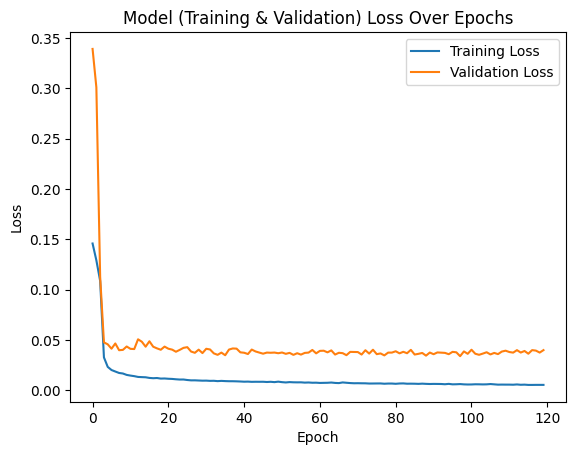

In [ ]:
# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = rnn_model.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 0s 3ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

print(comparison_df.head())

              Actual  Predicted
dteday                         
2012-10-29  0.722350   0.669857
2012-10-30  0.080285   0.643020
2012-10-31  0.619944   0.617802
2012-11-01  0.670651   0.598988
2012-11-02  0.653869   0.553241


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  5979.424805     -6.778698
2012-10-30  1096.000000  5757.132812    425.285841
2012-10-31  5566.000000  5548.252441     -0.318857
2012-11-01  5986.000000  5392.415527     -9.916212
2012-11-02  5847.000000  5013.498047    -14.255207


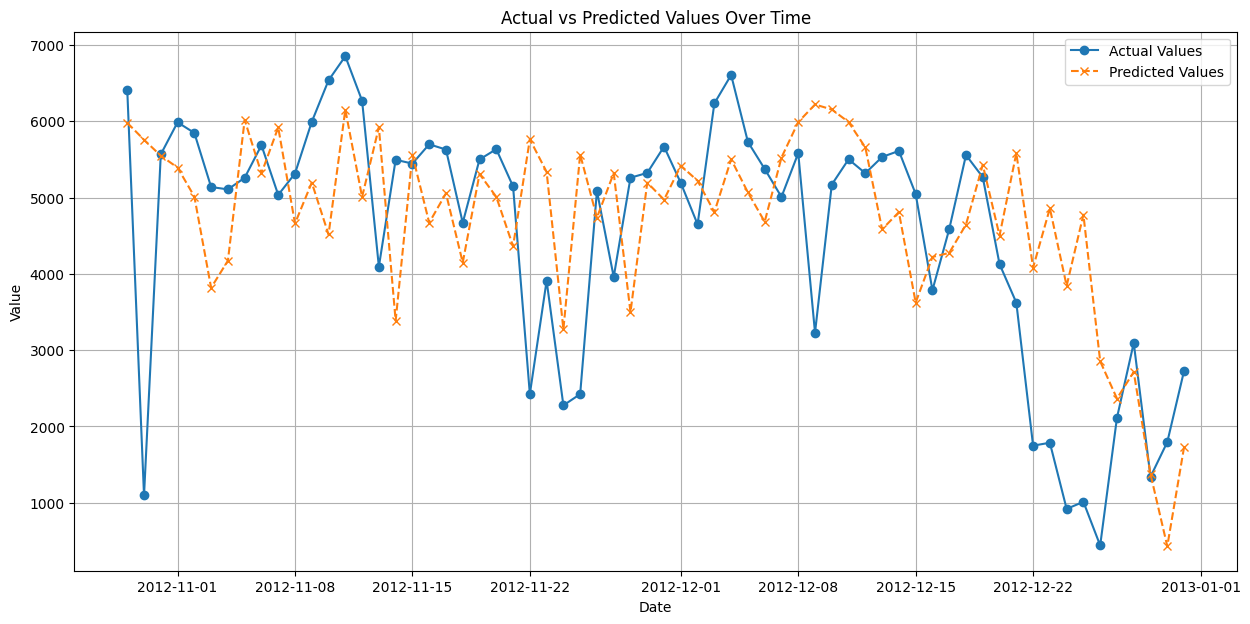

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculing error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)  # Calculate RMSE

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.0329807665746018
Mean Absolute Error: 0.13672280599125827
Root Mean Squared Error: 0.18160607526897826


# Data Modelling: Modified SimpleRNN

In [ ]:
# Parameters to tune
units_options = [30, 50, 100]  # Different unit options for SimpleRNN layers
dropout_options = [0.2, 0.3, 0.5]  # Different dropout rates

In [ ]:
# Attempt to find the best hyperparameter for SimpleRNN model #2

# Best model and score tracker
best_rnn_model = None
best_rnn_loss = np.inf
best_rnn_history2 = None

# Loop through all the combinations of parameters
for units in units_options:
    for dropout in dropout_options:
        # Reinitialize data generators for each iteration
        train_generator = TimeseriesGenerator(data=X_train.values, targets=y_train.values, length=n_input, batch_size=batch_size, shuffle=False)
        val_generator = TimeseriesGenerator(data=X_val.values, targets=y_val.values, length=n_input, batch_size=batch_size, shuffle=False)

        # RNN Model building
        rnn_model2 = Sequential()
        l2_regularizer = l2(0.001)

        # Adding first SimpleRNN layer with dropout
        rnn_model2.add(SimpleRNN(units=50, activation='tanh', return_sequences=True,
                                 input_shape=(n_input, X_train.shape[1]), kernel_regularizer=l2_regularizer))
        rnn_model2.add(Dropout(dropout))

        # Adding second SimpleRNN layer
        rnn_model2.add(SimpleRNN(units=units, activation='tanh', return_sequences=False))

        # Adding output layer
        rnn_model2.add(Dense(1, activation='relu'))

        # Compile the model
        optimizer = Adam(learning_rate=0.0001)
        rnn_model2.compile(optimizer=optimizer, loss='mse')

        # Model checkpointing
        model_checkpoint = ModelCheckpoint(f'best_rnn_model_units_{units}_dropout_{dropout}.h5', save_best_only=True, monitor='val_loss')

        # Train the model
        rnn_history2 = rnn_model2.fit(train_generator, epochs=120, validation_data=val_generator, verbose=0, callbacks=[model_checkpoint])

        # Record the best result based on validation loss
        val_loss = np.min(rnn_history.history['val_loss'])
        if val_loss < best_rnn_loss:
            best_rnn_loss = val_loss
            best_rnn_model = rnn_model2
            best_rnn_model_path = f'best_rnn_model_units_{units}_dropout_{dropout}.h5'
            best_rnn_history2 = rnn_history2.history
            print(f"New best RNN model found: Units={units}, Dropout={dropout}, Validation Loss={val_loss}")

# Summary of best model after tuning
print(f"Final best RNN model path: {best_rnn_model_path}")


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


New best RNN model found: Units=30, Dropout=0.2, Validation Loss=0.03382427617907524
Final best RNN model path: best_rnn_model_units_30_dropout_0.2.h5


In [ ]:
### JUST FOR MODEL ARCHITECTURE CHECKING AFTER OBTAINING BEST HYPERPARAMETERS ###

# Define the model architecture
rnn_model2_check = Sequential()

rnn_model2_check.add(SimpleRNN(30, activation = 'tanh', input_shape=(n_input, X_train.shape[1]), return_sequences=True, kernel_regularizer=l2_regularizer))
rnn_model2_check.add(Dropout(0.2))

rnn_model2_check.add(SimpleRNN(30, activation='tanh', return_sequences=False))

rnn_model2_check.add(Dense(1, activation = 'relu'))

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

rnn_model2_check.compile(optimizer=optimizer, loss='mse')

# Model summary
rnn_model2_check.summary()

Model: "sequential_69"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_49 (SimpleRNN)   (None, 10, 30)            1530      
                                                                 
 dropout_63 (Dropout)        (None, 10, 30)            0         
                                                                 
 simple_rnn_50 (SimpleRNN)   (None, 30)                1830      
                                                                 
 dense_66 (Dense)            (None, 1)                 31        
                                                                 
Total params: 3391 (13.25 KB)
Trainable params: 3391 (13.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


13/13 [==============================] - 0s 3ms/step - loss: 0.0436
Training Loss (MSE): 0.022640680894255638
Validation Loss (MSE): 0.05343562364578247
Best Training Loss (MSE): 0.02253236249089241
Best Validation Loss (MSE): 0.046061716973781586
Test Loss (MSE): 0.043579425662755966


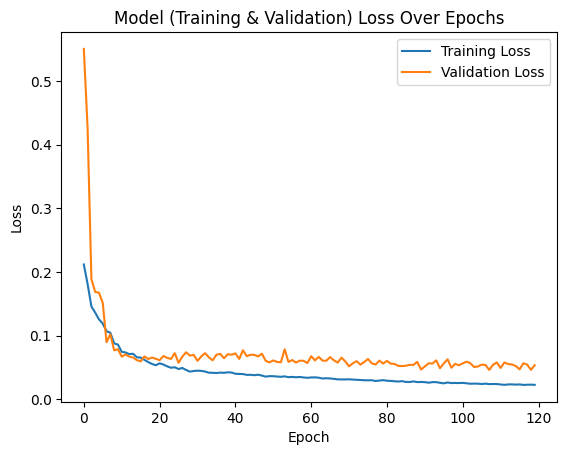

In [ ]:
# Load the best model from the saved file after parameters loop
best_rnn2 = load_model(best_rnn_model_path)

# Evaluate the best model on the test generator
test_loss = best_rnn2.evaluate(test_generator)

# Extract training and validation losses from the best model's history
train_loss = best_rnn_history2['loss']
val_loss = best_rnn_history2['val_loss']

# Final train and validation loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validtion loss achieved
best_train_loss = min(best_rnn_history2['loss'])
best_val_loss = min(best_rnn_history2['val_loss'])

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')
print(f'Test Loss (MSE): {test_loss}')

# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = best_rnn2.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 0s 3ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

print(comparison_df.tail())

              Actual  Predicted  Difference %
dteday                                       
2012-12-27  0.203187   0.339334     67.005504
2012-12-28  0.321623   0.325586      1.232348
2012-12-29  0.109864   0.412047    275.053437
2012-12-30  0.164795   0.273078     65.707075
2012-12-31  0.277436   0.261948     -5.582476


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  5351.426270    -16.569413
2012-10-30  1096.000000  4873.676758    344.678536
2012-10-31  5566.000000  5210.025391     -6.395519
2012-11-01  5986.000000  5879.816406     -1.773866
2012-11-02  5847.000000  5652.597656     -3.324822


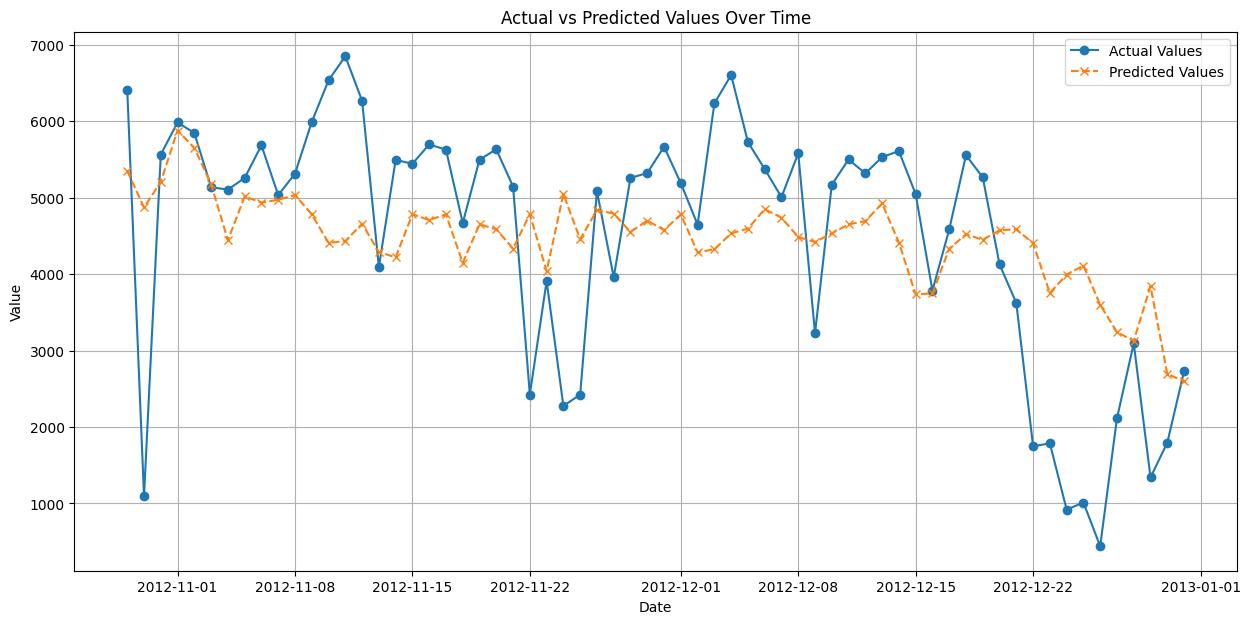

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculing error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.0288521234701288
Mean Absolute Error: 0.13067281304530567
Root Mean Squared Error: 0.16985912830969316


# Data Modelling: LSTM

In [ ]:
# Define basic LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='tanh', input_shape=(n_input,X_train.shape[1])))
lstm_model.add(Dense(1, activation= 'relu'))

adam = Adam(learning_rate=0.0001)
lstm_model.compile(optimizer=adam, loss='mse')

In [ ]:
# Model summary
lstm_model.summary()

Model: "sequential_61"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_59 (LSTM)              (None, 50)                14200     
                                                                 
 dense_61 (Dense)            (None, 1)                 51        
                                                                 
Total params: 14251 (55.67 KB)
Trainable params: 14251 (55.67 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Fit the model with the generators
lstm_history = lstm_model.fit(train_generator, epochs=120, validation_data=val_generator)

Epoch 1/120
101/101 [==============================] - 3s 13ms/step - loss: 0.0985 - val_loss: 0.0791
Epoch 2/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0249 - val_loss: 0.0444
Epoch 3/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0172 - val_loss: 0.0348
Epoch 4/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0150 - val_loss: 0.0259
Epoch 5/120
101/101 [==============================] - 1s 7ms/step - loss: 0.0140 - val_loss: 0.0289
Epoch 6/120
101/101 [==============================] - 1s 11ms/step - loss: 0.0137 - val_loss: 0.0225
Epoch 7/120
101/101 [==============================] - 1s 11ms/step - loss: 0.0134 - val_loss: 0.0249
Epoch 8/120
101/101 [==============================] - 1s 11ms/step - loss: 0.0130 - val_loss: 0.0252
Epoch 9/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0126 - val_loss: 0.0247
Epoch 10/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0126 - va

In [ ]:
# Printing train loss, validation loss and MSE
train_loss = lstm_history.history['loss']
val_loss = lstm_history.history['val_loss']

# Final train and validation loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validation loss achieved
best_train_loss = min(lstm_history.history['loss'])
best_val_loss = min(lstm_history.history['val_loss'])

test_loss = lstm_model.evaluate(test_generator)

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')
print(f'Test Loss (MSE): {test_loss}')

13/13 [==============================] - 0s 3ms/step - loss: 0.0419
Training Loss (MSE): 0.007970969192683697
Validation Loss (MSE): 0.0612519346177578
Best Training Loss (MSE): 0.00754664046689868
Best Validation Loss (MSE): 0.0225120447576046
Test Loss (MSE): 0.041908688843250275


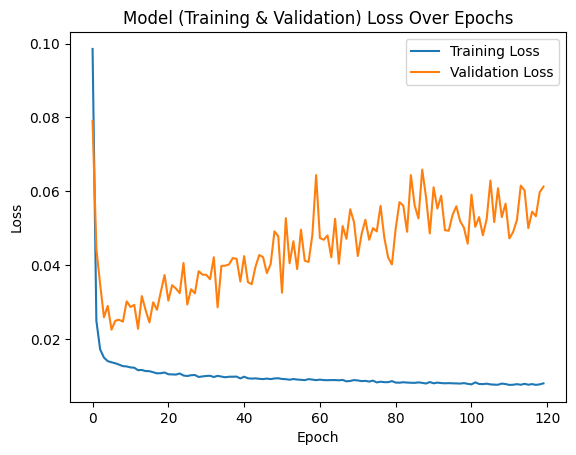

In [ ]:
# Plot the training and validation loss (LSTM)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = lstm_model.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 1s 5ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

print(comparison_df.head())

              Actual  Predicted
dteday                         
2012-10-29  0.722350   0.464182
2012-10-30  0.080285   0.362765
2012-10-31  0.619944   0.477383
2012-11-01  0.670651   0.494401
2012-11-02  0.653869   0.464011


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  4275.822266    -33.338451
2012-10-30  1096.000000  3435.782715    213.483824
2012-10-31  5566.000000  4385.167480    -21.215101
2012-11-01  5986.000000  4526.120605    -24.388229
2012-11-02  5847.000000  4274.404297    -26.895771


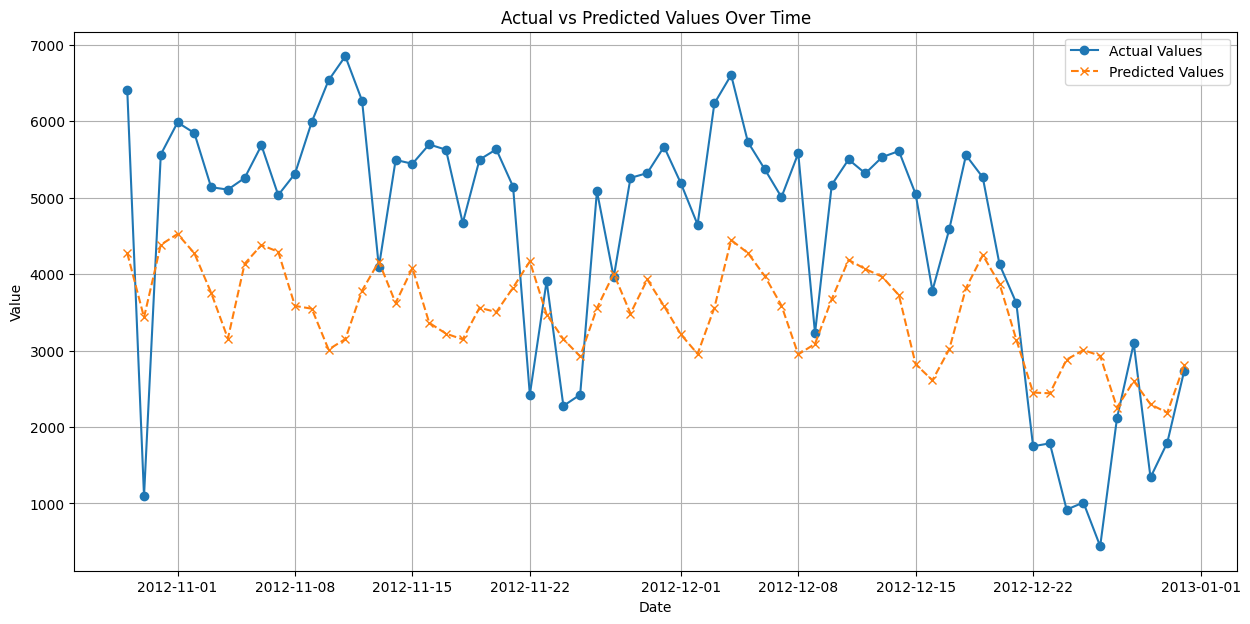

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculating error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.04190868362092806
Mean Absolute Error: 0.18067584133205775
Root Mean Squared Error: 0.20471610493785794


# Data Modelling: Modified LSTM

In [ ]:
# Attempt to find the best hyperparameter for LSTM model #2

# Best model and score tracker
best_lstm_model = None
best_loss = np.inf
best_lstm_history2 = None

# Loop through all the combinations of parameters
for units in units_options:
    for dropout in dropout_options:
        # Reinitialize data generators for each iteration
        train_generator = TimeseriesGenerator(data=X_train.values, targets=y_train.values, length=n_input, batch_size=batch_size, shuffle=False)
        val_generator = TimeseriesGenerator(data=X_val.values, targets=y_val.values, length=n_input, batch_size=batch_size, shuffle=False)

        # Model building
        lstm_model2 = Sequential()
        l2_regularizer = l2(0.001)

        # Adding first LSTM layer with dropout
        lstm_model2.add(LSTM(units=units, activation='tanh', return_sequences=True,
                             input_shape=(n_input, X_train.shape[1]), kernel_regularizer=l2_regularizer))
        lstm_model2.add(Dropout(dropout))

        # Adding second LSTM layer
        lstm_model2.add(LSTM(units=units, activation='tanh', return_sequences=False))

        # Adding output layer
        lstm_model2.add(Dense(units=1 , activation = 'relu'))

        # Compile the model
        optimizer = Adam(learning_rate=0.0001)
        lstm_model2.compile(optimizer=optimizer, loss='mse')

        # Model checkpointing
        model_checkpoint = ModelCheckpoint(f'best_lstm_model_units_{units}_dropout_{dropout}.h5', save_best_only=True, monitor='val_loss')

        # Train the model
        lstm_history2 = lstm_model2.fit(train_generator, epochs=120, validation_data=val_generator, verbose=0, callbacks=[model_checkpoint])

        # Record the best result based on validation loss
        val_loss = np.min(lstm_history2.history['val_loss'])
        if val_loss < best_loss:
            best_loss = val_loss
            best_lstm_model = lstm_model2
            best_lstm_model_path = f'best_lstm_model_units_{units}_dropout_{dropout}.h5'
            best_lstm_history2 = lstm_history2.history
            print(f"New best model found: Units={units}, Dropout={dropout}, Validation Loss={val_loss}")

# Summary of best model after tuning
print(f"Final best model path: {best_lstm_model_path}")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


New best model found: Units=30, Dropout=0.2, Validation Loss=0.03250322490930557
New best model found: Units=30, Dropout=0.5, Validation Loss=0.024726251140236855
Final best model path: best_lstm_model_units_30_dropout_0.5.h5


In [ ]:
### JUST FOR MODEL ARCHITECTURE CHECKING AFTER OBTAINING BEST HYPERPARAMETERS ###

# Define the model architecture
lstm_model2_check = Sequential()

lstm_model2_check.add(LSTM(100, input_shape=(n_input, X_train.shape[1]), activation='tanh', return_sequences=True, kernel_regularizer=l2_regularizer))
lstm_model2_check.add(Dropout(0.3))

lstm_model2_check.add(LSTM(100, activation='tanh', return_sequences=False))

lstm_model2_check.add(Dense(1, activation = 'relu'))

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

lstm_model2_check.compile(optimizer=optimizer, loss='mse')

# Model summary
lstm_model2_check.summary()

Model: "sequential_60"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_57 (LSTM)              (None, 10, 100)           48400     
                                                                 
 dropout_54 (Dropout)        (None, 10, 100)           0         
                                                                 
 lstm_58 (LSTM)              (None, 100)               80400     
                                                                 
 dense_60 (Dense)            (None, 1)                 101       
                                                                 
Total params: 128901 (503.52 KB)
Trainable params: 128901 (503.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


13/13 [==============================] - 1s 6ms/step - loss: 0.0384
Training Loss (MSE): 0.014468456618487835
Validation Loss (MSE): 0.02798728086054325
Best Training Loss (MSE): 0.013767687603831291
Best Validation Loss (MSE): 0.024726251140236855
Test Loss (MSE): 0.03844448924064636


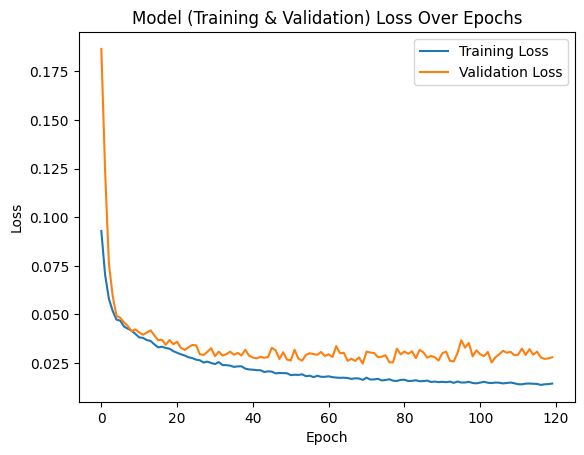

In [ ]:
# Load the best model from the saved file
best_lstm2 = load_model(best_lstm_model_path)

# Evaluate the best model on the test generator
test_loss = best_lstm2.evaluate(test_generator)

# Extract training and validation losses from the best model's history
train_loss = best_lstm_history2['loss']
val_loss = best_lstm_history2['val_loss']

# Final train and validation loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validation loss achieved
best_train_loss = min(best_lstm_history2['loss'])
best_val_loss = min(best_lstm_history2['val_loss'])

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')

print(f'Test Loss (MSE): {test_loss}')

# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = best_lstm2.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 1s 4ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

print(comparison_df.head())

              Actual  Predicted
dteday                         
2012-10-29  0.722350   0.628503
2012-10-30  0.080285   0.628383
2012-10-31  0.619944   0.637059
2012-11-01  0.670651   0.644605
2012-11-02  0.653869   0.643909


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  5636.891113    -12.118917
2012-10-30  1096.000000  5635.895996    414.224087
2012-10-31  5566.000000  5707.757324      2.546844
2012-11-01  5986.000000  5770.265625     -3.603982
2012-11-02  5847.000000  5764.496094     -1.411047


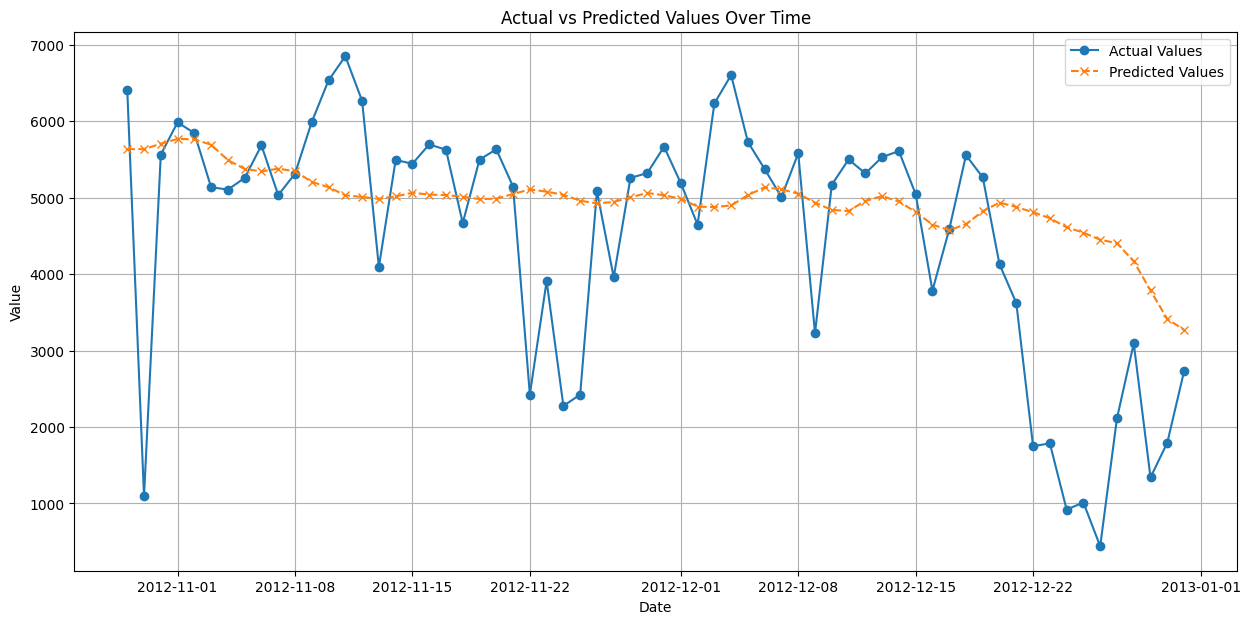

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculating error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.03324400045735698
Mean Absolute Error: 0.12805683472683366
Root Mean Squared Error: 0.18232937354512296


# Data Modelling: GRU

In [ ]:
# Define basic GRU

gru_model = Sequential()
gru_model.add(GRU(50, activation='tanh', input_shape=(n_input, X_train.shape[1])))
gru_model.add(Dense(1 , activation = 'relu'))

adam = Adam(learning_rate=0.0001)
gru_model.compile(optimizer=adam, loss='mse')

In [ ]:
# Model summary
gru_model.summary()

Model: "sequential_62"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_19 (GRU)                (None, 50)                10800     
                                                                 
 dense_62 (Dense)            (None, 1)                 51        
                                                                 
Total params: 10851 (42.39 KB)
Trainable params: 10851 (42.39 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Fit the model with the generators
gru_history = gru_model.fit(train_generator, epochs=120, validation_data=val_generator)

Epoch 1/120
101/101 [==============================] - 5s 22ms/step - loss: 0.1422 - val_loss: 0.4118
Epoch 2/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0779 - val_loss: 0.2322
Epoch 3/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0487 - val_loss: 0.2135
Epoch 4/120
101/101 [==============================] - 1s 9ms/step - loss: 0.0343 - val_loss: 0.1001
Epoch 5/120
101/101 [==============================] - 1s 9ms/step - loss: 0.0256 - val_loss: 0.0917
Epoch 6/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0218 - val_loss: 0.0453
Epoch 7/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0190 - val_loss: 0.0366
Epoch 8/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0171 - val_loss: 0.0262
Epoch 9/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0163 - val_loss: 0.0284
Epoch 10/120
101/101 [==============================] - 1s 8ms/step - loss: 0.0159 - val_l

In [ ]:
# Printing train loss, validation loss and MSE
train_loss = gru_history.history['loss']
val_loss = gru_history.history['val_loss']

# Final train and valition loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validation loss achieved
best_train_loss = min(gru_history.history['loss'])
best_val_loss = min(gru_history.history['val_loss'])

test_loss = gru_model.evaluate(test_generator)

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')
print(f'Test Loss (MSE): {test_loss}')

13/13 [==============================] - 0s 3ms/step - loss: 0.0247
Training Loss (MSE): 0.008525884710252285
Validation Loss (MSE): 0.02312447503209114
Best Training Loss (MSE): 0.008525884710252285
Best Validation Loss (MSE): 0.018133528530597687
Test Loss (MSE): 0.024721551686525345


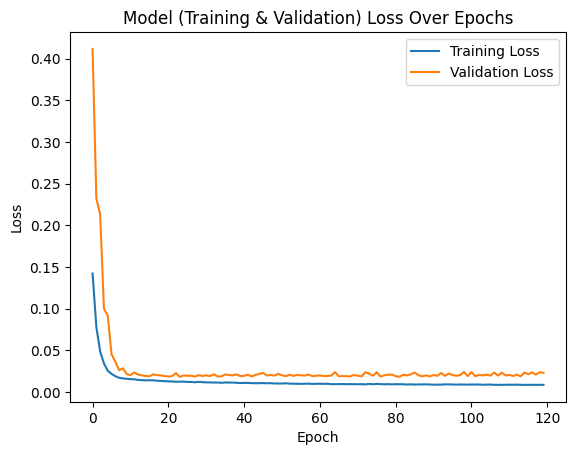

In [ ]:
# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = gru_model.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 1s 3ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

print(comparison_df.head())

              Actual  Predicted
dteday                         
2012-10-29  0.722350   0.540000
2012-10-30  0.080285   0.412596
2012-10-31  0.619944   0.574322
2012-11-01  0.670651   0.594553
2012-11-02  0.653869   0.573322


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  4903.823242    -23.547699
2012-10-30  1096.000000  3848.533936    251.143607
2012-10-31  5566.000000  5188.111328     -6.789232
2012-11-01  5986.000000  5355.685059    -10.529819
2012-11-02  5847.000000  5179.827637    -11.410507


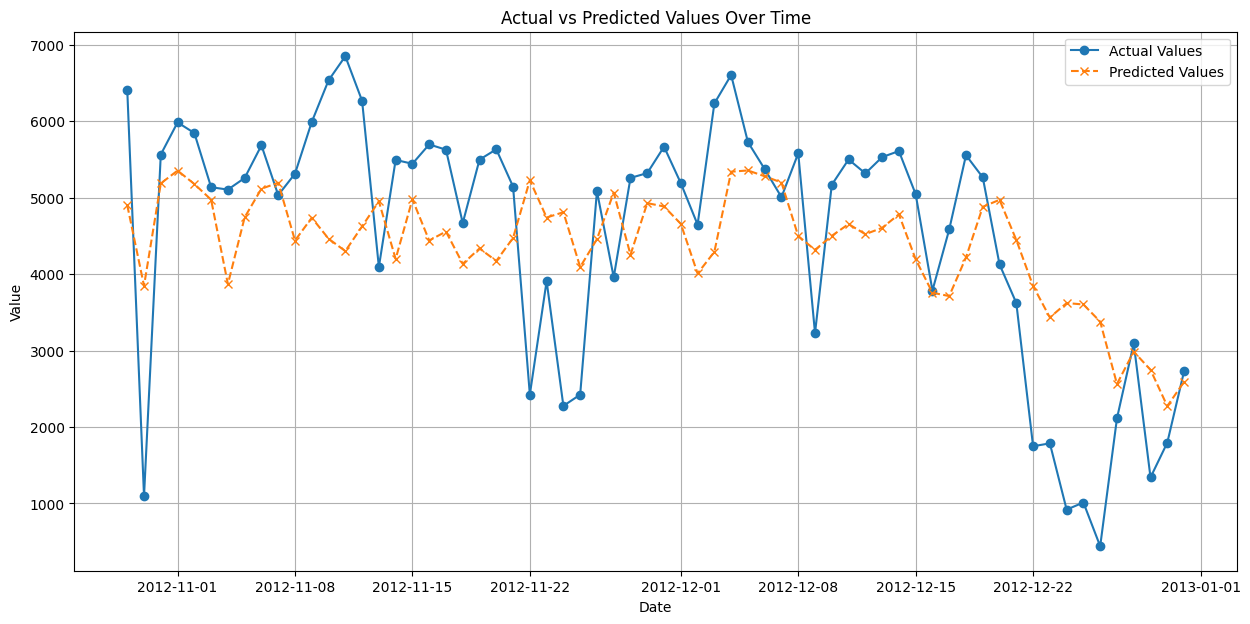

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculating error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.024721552395423618
Mean Absolute Error: 0.12917609475087127
Root Mean Squared Error: 0.15723088880822247


# Data Modelling: Modified GRU

In [ ]:
# Attempt to find the best hyperparameter for GRU model #2

# Best model and score tracker
best_gru_model = None
best_loss = np.inf
best_gru_history2 = None

# Loop through all the combinations of parameters
for units in units_options:
    for dropout in dropout_options:
        # Reinitialize data generators for each iteration
        train_generator = TimeseriesGenerator(data=X_train.values, targets=y_train.values, length=n_input, batch_size=batch_size, shuffle=False)
        val_generator = TimeseriesGenerator(data=X_val.values, targets=y_val.values, length=n_input, batch_size=batch_size, shuffle=False)

        # Model building
        gru_model2 = Sequential()
        l2_regularizer = l2(0.001)  # Example L2 regularization factor

        # Adding GRU layer with dropout
        gru_model2.add(GRU(units=units, activation='tanh', return_sequences=True,
                           input_shape=(n_input, X_train.shape[1]), kernel_regularizer=l2_regularizer))
        gru_model2.add(Dropout(dropout))

        # Adding another GRU hidden layer
        gru_model2.add(GRU(units=units, activation='tanh', return_sequences=False))

        # Adding output layer
        gru_model2.add(Dense(units=1, activation = 'relu'))

        # Compile the model
        optimizer = Adam(learning_rate=0.0001)
        gru_model2.compile(optimizer=optimizer, loss='mse')

        # Model checkpointing
        model_checkpoint = ModelCheckpoint(f'best_gru_model_units_{units}_dropout_{dropout}.h5', save_best_only=True, monitor='val_loss')

        # Train the model
        gru_history2 = gru_model2.fit(train_generator, epochs=120, validation_data=val_generator, verbose=0, callbacks=[model_checkpoint])

        # Record the best result based on validation loss
        val_loss = np.min(gru_history2.history['val_loss'])
        if val_loss < best_loss:
            best_loss = val_loss
            best_gru_model = gru_model2
            best_gru_model_path = f'best_gru_model_units_{units}_dropout_{dropout}.h5'
            best_gru_history2 = gru_history2.history
            print(f"New best model found: Units={units}, Dropout={dropout}, Validation Loss={val_loss}")

# Summary of best model after tuning
print(f"Final best model path: {best_gru_model_path}")


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


New best model found: Units=30, Dropout=0.2, Validation Loss=0.023202387616038322
New best model found: Units=30, Dropout=0.3, Validation Loss=0.019982581958174706
Final best model path: best_gru_model_units_30_dropout_0.3.h5


In [ ]:
### JUST FOR MODEL ARCHITECTURE CHECKING AFTER OBTAINING BEST HYPERPARAMETERS ###

# Define the model architecture
gru_model2_check = Sequential()

gru_model2_check.add(GRU(30, input_shape=(n_input, X_train.shape[1]), activation = 'tanh', return_sequences=True, kernel_regularizer=l2_regularizer))
gru_model2_check.add(Dropout(0.2))

gru_model2_check.add(GRU(30, activation='tanh', return_sequences=False))

gru_model2_check.add(Dense(1, activation = 'relu'))

learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)

gru_model2_check.compile(optimizer=optimizer, loss='mse')

# Model summary
gru_model2_check.summary()

Model: "sequential_72"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_40 (GRU)                (None, 10, 30)            4680      
                                                                 
 dropout_65 (Dropout)        (None, 10, 30)            0         
                                                                 
 gru_41 (GRU)                (None, 30)                5580      
                                                                 
 dense_68 (Dense)            (None, 1)                 31        
                                                                 
Total params: 10291 (40.20 KB)
Trainable params: 10291 (40.20 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


13/13 [==============================] - 1s 4ms/step - loss: 0.0366
Training Loss (MSE): 0.015148256905376911
Validation Loss (MSE): 0.02523408830165863
Best Training Loss (MSE): 0.015140805393457413
Best Validation Loss (MSE): 0.019982581958174706
Test Loss (MSE): 0.03661429509520531


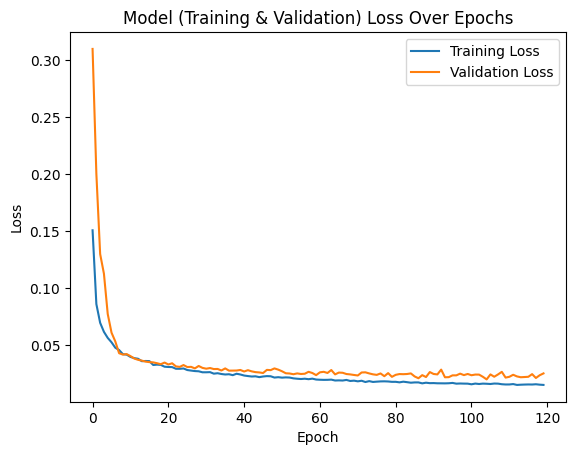

In [ ]:
# Load the best model from the saved file
best_gru2 = load_model(best_gru_model_path)

# Evaluate the best model on the test generator
test_loss = best_gru2.evaluate(test_generator)

# Extract training and validation losses from the best model's history
train_loss = best_gru_history2['loss']
val_loss = best_gru_history2['val_loss']

# Final train and validation loss achieved
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (lowest) train and validation loss achieved
best_train_loss = min(best_gru_history2['loss'])
best_val_loss = min(best_gru_history2['val_loss'])

print(f'Training Loss (MSE): {final_train_loss}')
print(f'Validation Loss (MSE): {final_val_loss}')
print(f'Best Training Loss (MSE): {best_train_loss}')
print(f'Best Validation Loss (MSE): {best_val_loss}')
print(f'Test Loss (MSE): {test_loss}')

# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model (Training & Validation) Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Generate predictions for the test data
predictions = best_gru2.predict(test_generator)

# Extract the actual target values from the test generator
actuals = np.concatenate([y for x, y in test_generator])

13/13 [==============================] - 1s 4ms/step


In [ ]:
# Selecting the dates of predictions
test_dates = df.index[-len(predictions):]

In [ ]:
# Flatten predictions array to make it 1 dimensional
predictions = predictions.flatten()

# Retrieve actual values
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
}, index=test_dates)

print(comparison_df.head())

              Actual  Predicted
dteday                         
2012-10-29  0.722350   0.646420
2012-10-30  0.080285   0.648268
2012-10-31  0.619944   0.660425
2012-11-01  0.670651   0.664691
2012-11-02  0.653869   0.654527


In [ ]:
# Flatten predictions array to make it 1-dimensional
predictions = predictions.flatten()

# Actuals are scaled and need to be inverse transformed
actuals_original = scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()
predictions_original = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Create DataFrame with original values
comparison_df = pd.DataFrame({
    'Actual': actuals_original,
    'Predicted': predictions_original
}, index=test_dates)

# Calculate the percentage difference
comparison_df['Difference %'] = ((comparison_df['Predicted'] - comparison_df['Actual']) / comparison_df['Actual']) * 100

# Print the last few rows of the DataFrame
print(comparison_df.head())

                 Actual    Predicted  Difference %
dteday                                            
2012-10-29  6414.225806  5785.297852     -9.805204
2012-10-30  1096.000000  5800.606445    429.252413
2012-10-31  5566.000000  5901.303223      6.024133
2012-11-01  5986.000000  5936.637695     -0.824629
2012-11-02  5847.000000  5852.444824      0.093122


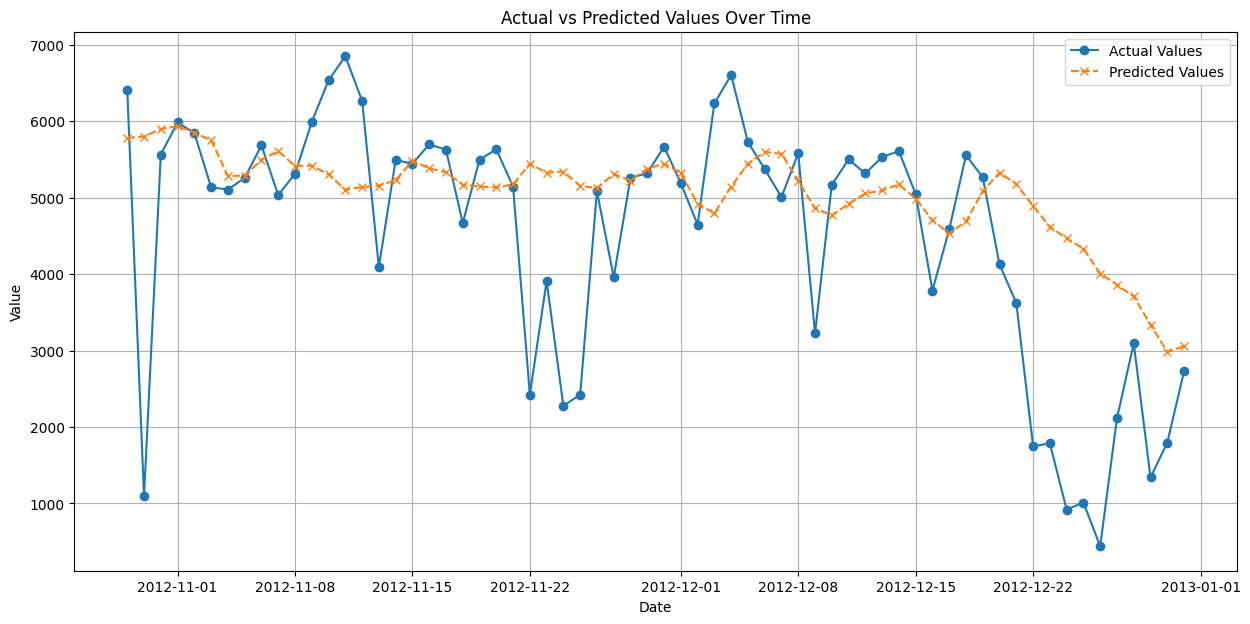

In [ ]:
# Plotting the predictions vs actual values over time
plt.figure(figsize=(15, 7))
plt.plot(comparison_df['Actual'], label='Actual Values', marker='o')
plt.plot(comparison_df['Predicted'], label='Predicted Values', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculating error metrics of predictions from errors
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 0.03159030351511863
Mean Absolute Error: 0.11887739500774011
Root Mean Squared Error: 0.17773661275921354
